# 📈 Visualización y Evaluación de Métricas (Fase 3: mAP y PHC)

Este notebook permite cargar modelos dinámicamente, evaluar contra datasets HDF5 masivos y generar reportes de grado científico utilizando **Supresión de No Máximos (DBSCAN 3D)**.

**Características:**
* **Métricas Oficiales:** Implementa mean Average Precision (mAP) y Precision at Highest Confidence (PHC).
* **Preprocesamiento Flexible:** Activa/Desactiva FPS y Normalización al vuelo.
* **Auto-Reporte:** Guarda automáticamente los hiperparámetros y resultados en un `.json`.

In [1]:
import sys
import importlib
import os
import json
from datetime import datetime
import h5py
import lzma
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.cluster import DBSCAN

pd.set_option('display.max_columns', 200)

# =======================================================
# 1. CONFIGURACIÓN DEL ENTORNO Y RUTAS
# =======================================================
PROJECT_ROOT = Path("home/vimunoz/proyecto/PCT_Symmetria").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    print(f"✅ Raíz del proyecto agregada al sys.path: {PROJECT_ROOT}")


#LOGS_ROOT = "C:/Users/vicho/OneDrive/Escritorio/Tesis II/relela/easy-10k-32/version_2"
#TEST_H5_PATH = "C:/datasets/Symmetria-Easy-10k-preproc/test.h5"
LOGS_ROOT = "/home/vimunoz/proyectos/PCT_Symmetria/logs/easy-10k-32/version_2"
TEST_H5_PATH = "/data/vimunoz/Symmetria-Hard-10k-preproc/test.h5"
CHECKPOINT_PATH = LOGS_ROOT+"/checkpoints/last.ckpt"

MODEL_CLASS_PATH = "src.model.LightningSymmetryModel.LightningSymmetryModel"

# =======================================================
# 2. PARÁMETROS GLOBALES DEL EXPERIMENTO
# =======================================================
# Switches de preprocesamiento (False si el HDF5 ya está procesado)
APPLY_FPS = False 
APPLY_NORMALIZATION = False
NUM_POINTS_FPS = 1024

# Umbrales geométricos estrictos (Papers)
CONFIDENCE_THRESHOLD = 0.1  # Filtro inicial de ruido
ANGLE_THRESHOLD = 1.0       # 1 grado de tolerancia angular
EPSILON_RATE = 0.01         # 1% de la diagonal (tolerancia de distancia)
DBSCAN_EPS = 0.005          # Radio de búsqueda para agrupar normales
DBSCAN_MIN_SAMPLES = 10     # Puntos mínimos para confirmar un plano

✅ Raíz del proyecto agregada al sys.path: /home/vimunoz/proyectos/PCT_Symmetria/home/vimunoz/proyecto/PCT_Symmetria


## Funciones Auxiliares

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# =======================================================
# 3. GRÁFICAS DE ENTRENAMIENTO (metrics.csv)
# =======================================================
def plot_training_curves(logs_dir):
    candidates = sorted(Path(logs_dir).rglob('metrics.csv'))
    if not candidates:
        print("⚠️ No se encontró metrics.csv en la ruta proporcionada.")
        return
        
    metrics_csv = str(candidates[-1])
    df = pd.read_csv(metrics_csv)
    
    out = df[['epoch', 'train_loss', 'val_loss']].copy().sort_values(['epoch'])
    agg = out.groupby('epoch').agg(lambda s: s.dropna().iloc[-1] if len(s.dropna()) else np.nan).reset_index()

    plt.figure(figsize=(10, 5))
    if 'train_loss' in agg.columns:
        train_data = agg[['epoch', 'train_loss']].dropna()
        plt.plot(train_data['epoch'], train_data['train_loss'], label='Train Loss', marker='o', color='tab:blue')
    if 'val_loss' in agg.columns:
        val_data = agg[['epoch', 'val_loss']].dropna()
        plt.plot(val_data['epoch'], val_data['val_loss'], label='Val Loss', marker='s', color='tab:orange')
        
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Curvas de Aprendizaje (PCT_M1)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
# =======================================================
# 4. FUNCIONES AUXILIARES Y DE CARGA DINÁMICA
# =======================================================
def load_model_dynamically(class_path, ckpt_path):
    module_name, class_name = class_path.rsplit('.', 1)
    module = importlib.import_module(module_name)
    model_class = getattr(module, class_name)
    
    # Detectamos el hardware actual y forzamos el mapeo de los pesos a este dispositivo
    target_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    return model_class.load_from_checkpoint(ckpt_path, map_location=target_device)

def apply_fps_on_the_fly(points, num_samples):
    num_points = points.shape[0]
    if num_points <= num_samples: return points
    centroids = torch.zeros(num_samples, dtype=torch.long)
    distance = torch.ones(num_points) * 1e10
    farthest = torch.randint(0, num_points, (1,), dtype=torch.long)
    for i in range(num_samples):
        centroids[i] = farthest
        centroid = points[farthest, :].view(1, 3)
        dist = torch.sum((points - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return points[centroids]

def apply_normalization_on_the_fly(points, eps=1.0e-9):
    centroid = torch.mean(points, dim=0)
    points = points - centroid
    m = torch.max(torch.sqrt(torch.sum(points ** 2, dim=1)))
    return points / (m + eps)

In [5]:
# =======================================================
# 5. MATEMÁTICAS GEOMÉTRICAS Y CLUSTERING
# =======================================================
def compute_ap(tp_array, fp_array, num_gt):
    if num_gt == 0 or len(tp_array) == 0: return 0.0
    cum_tp = np.cumsum(tp_array)
    cum_fp = np.cumsum(fp_array)
    recalls = cum_tp / num_gt
    precisions = cum_tp / (cum_tp + cum_fp)
    
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))
    
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])
        
    indices = np.where(recalls[1:] != recalls[:-1])[0] + 1
    ap = np.sum((recalls[indices] - recalls[indices - 1]) * precisions[indices])
    return ap

def check_match(pred_normal, pred_point, gt_planes, matched_gt, diag=1.0, theta=1.0, epsilon_rate=0.01):
    epsilon = diag * epsilon_rate
    for idx, gt_plane in enumerate(gt_planes):
        if idx in matched_gt: continue
            
        gt_normal = gt_plane[:3]
        gt_point = gt_plane[3:6] if len(gt_plane) >= 6 else np.zeros(3)
        
        cos_angle = np.clip(np.dot(pred_normal, gt_normal), -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))
        angle_err = min(angle_deg, 180.0 - angle_deg)
        dist_err = np.abs(np.dot((pred_point - gt_point), gt_normal))
        
        if angle_err <= theta and dist_err <= epsilon:
            return True, angle_err, idx
            
    return False, None, -1

def extract_final_symmetries(pred_normals, pred_confs, pred_centers, conf_threshold=0.8, eps=0.15, min_samples=10):
    M = pred_normals.shape[2] 
    normals_flat = pred_normals.reshape(-1, 3).cpu().numpy()
    confs_flat = pred_confs.reshape(-1).cpu().numpy()
    
    centers_expanded = pred_centers.unsqueeze(2).expand(-1, -1, M, -1)
    centers_flat = centers_expanded.reshape(-1, 3).cpu().numpy()
    
    mask = confs_flat > conf_threshold
    valid_normals = normals_flat[mask]
    valid_confs = confs_flat[mask]
    valid_centers = centers_flat[mask]
    
    if len(valid_normals) == 0:
        return np.array([]), np.array([]), np.array([])
    
    #flip_mask = valid_normals[:, 2] < 0
    #valid_normals[flip_mask] *= -1
        
    #Calcula la matriz de distancias angulares (sin importar el signo)
    # np.dot(valid_normals, valid_normals.T) da el coseno entre todos los vectores.
    # np.abs() hace que n y -n sean idénticos (coseno absoluto).
    dot_products = np.abs(np.dot(valid_normals, valid_normals.T))
    dot_products = np.clip(dot_products, 0.0, 1.0) # Evitar errores de coma flotante
    distance_matrix = 1.0 - dot_products
    
    #Correr DBSCAN con la métrica precomputada
    clustering = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed').fit(distance_matrix)
    #clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(valid_normals)
    labels = clustering.labels_
    
    final_normals, final_confs, final_centers = [], [], []
    for label in set(labels):
        if label == -1: continue 
            
        cluster_mask = (labels == label)
        cluster_normals = valid_normals[cluster_mask]
        cluster_confs = valid_confs[cluster_mask]
        cluster_centers = valid_centers[cluster_mask]
        
        best_idx = np.argmax(cluster_confs)
        final_normals.append(cluster_normals[best_idx])
        final_confs.append(cluster_confs[best_idx])
        final_centers.append(cluster_centers[best_idx])
        
    return np.array(final_normals), np.array(final_confs), np.array(final_centers)

In [6]:
# =======================================================
# 6. EVALUACIÓN MASIVA (mAP y PHC)
# =======================================================
import yaml
from pathlib import Path

def evaluate_hdf5():
    print(f"🧠 Cargando modelo dinámicamente: {MODEL_CLASS_PATH}")
    model = load_model_dynamically(MODEL_CLASS_PATH, CHECKPOINT_PATH)
    model.eval()
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"⚡ Evaluando usando VRAM: {device}\n")
    
    true_positives, false_positives, false_negatives = 0, 0, 0
    angular_errors, list_aps, list_phcs = [], [], []

    print(f"📂 Abriendo base de datos HDF5: {TEST_H5_PATH}")
    with h5py.File(TEST_H5_PATH, 'r') as f:
        shape_ids = list(f.keys())
        
        with torch.no_grad():
            for shape_id in tqdm(shape_ids, desc="Evaluando Modelos 3D"):
                group = f[shape_id]
                points_np = group['points'][:]
                
                if 'planar_symmetries' in group:
                    gt_planes = group['planar_symmetries'][:]
                elif 'planes' in group:
                    gt_planes = group['planes'][:]
                else:
                    gt_planes = []
                
                has_gt_symmetry = len(gt_planes) > 0
                
                # Preprocesamiento
                t_points = torch.tensor(points_np, dtype=torch.float32)
                if APPLY_FPS: t_points = apply_fps_on_the_fly(t_points, NUM_POINTS_FPS)
                if APPLY_NORMALIZATION: t_points = apply_normalization_on_the_fly(t_points)
                
                points_tensor = t_points.transpose(0, 1).unsqueeze(0).to(device)
                
                # Predicción Neuronal
                pred = model(points_tensor)

                # NMS y Clustering
                final_n, final_c, final_cent = extract_final_symmetries(
                    pred[0], pred[1], pred[2], 
                    conf_threshold=CONFIDENCE_THRESHOLD,
                    eps=DBSCAN_EPS,
                    min_samples=DBSCAN_MIN_SAMPLES
                )

                shape_ap, shape_phc = 0.0, 0.0
                
                if len(final_n) > 0 and has_gt_symmetry:
                    sort_indices = np.argsort(final_c)[::-1]
                    sorted_normals = final_n[sort_indices]
                    sorted_centers = final_cent[sort_indices]
                    
                    matched_gt = set()
                    tp_array, fp_array = [], []
                    
                    for i in range(len(sorted_normals)):
                        is_match, ang_err, match_idx = check_match(
                            sorted_normals[i], sorted_centers[i], gt_planes, matched_gt,
                            theta=ANGLE_THRESHOLD, epsilon_rate=EPSILON_RATE
                        )
                        
                        if is_match:
                            tp_array.append(1)
                            fp_array.append(0)
                            matched_gt.add(match_idx)
                            true_positives += 1
                            angular_errors.append(ang_err)
                            
                            if i == 0: shape_phc = 1.0 
                        else:
                            tp_array.append(0)
                            fp_array.append(1)
                            false_positives += 1
                            
                    false_negatives += max(0, len(gt_planes) - len(matched_gt))
                    shape_ap = compute_ap(tp_array, fp_array, len(gt_planes))
                    
                elif has_gt_symmetry:
                    false_negatives += len(gt_planes)
                elif len(final_n) > 0 and not has_gt_symmetry:
                    false_positives += len(final_n)
                    
                list_aps.append(shape_ap)
                list_phcs.append(shape_phc)

    # --- Consolidación y Exportación ---
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    mAP = np.mean(list_aps) if list_aps else 0.0
    mPHC = np.mean(list_phcs) if list_phcs else 0.0
    mean_error = np.mean(angular_errors) if angular_errors else 0.0
    
    # 1. Extraer el nombre del dataset para crear una subcarpeta específica
    # TEST_H5_PATH es algo como "C:/datasets/Symmetria-Easy-100k-preproc/test.h5"
    dataset_name = TEST_H5_PATH.split('/')[-2] 
    base_dir = Path("resultados_evaluacion") / dataset_name
    os.makedirs(base_dir, exist_ok=True)

    # 2. Extraer SOLAMENTE el learning_rate desde hparams.yaml
    hparams_path = Path(LOGS_ROOT) / "hparams.yaml"
    learning_rate = None
    if hparams_path.exists():
        with open(hparams_path, 'r') as f:
            hparams = yaml.safe_load(f)
            # PyTorch Lightning guarda los parámetros del __init__ directo aquí
            learning_rate = hparams.get('learning_rate', "No encontrado")
    else:
        learning_rate = "hparams.yaml no encontrado"

    # 3. Construir el diccionario del reporte
    report = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_checkpoint": CHECKPOINT_PATH,
        "dataset_test": TEST_H5_PATH,
        "parameters": {
            "CONFIDENCE_THRESHOLD": float(CONFIDENCE_THRESHOLD),
            "ANGLE_THRESHOLD": float(ANGLE_THRESHOLD),
            "EPSILON_RATE": float(EPSILON_RATE),
            "DBSCAN_EPS": float(DBSCAN_EPS),
            "DBSCAN_MIN_SAMPLES": int(DBSCAN_MIN_SAMPLES),
            "learning_rate": learning_rate  # <--- Learning rate extraído dinámicamente
        },
        "metrics": {
            "mAP": float(round(mAP, 4)),
            "PHC": float(round(mPHC, 4)),
            "Precision": float(round(precision, 4)),
            "Recall": float(round(recall, 4)),
            "F1_Score": float(round(f1_score, 4)),
            "True_Positives": int(true_positives),
            "False_Positives": int(false_positives),
            "False_Negatives": int(false_negatives),
            "Mean_Angular_Error": float(round(mean_error, 4))
        }
    }
    safe_time_str = datetime.now().strftime('%d-%m-%y_%Hh%Mm')
    file_name = base_dir / f"eval_{safe_time_str}.json"
    with open(file_name, 'w') as f:
        json.dump(report, f, indent=4)
        
    print("\n" + "="*45)
    print(" 🏆 RESULTADOS OFICIALES FASE 3")
    print("="*45)
    print(f"Dataset:           {TEST_H5_PATH.split('/')[-2]}")
    print(f"Total evaluados:   {len(shape_ids)}")
    print("-" * 45)
    print(f"mAP (Promedio):    {mAP:.4f}")
    print(f"PHC (Top-1):       {mPHC:.4f}")
    print("-" * 45)
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1-Score:          {f1_score:.4f}")
    print(f"Error Ang. Medio:  {mean_error:.2f}°")
    print("="*45)
    print(f"✅ Reporte JSON guardado en: {file_name}")



## Graficar Entrenamiento (metrics.csv)

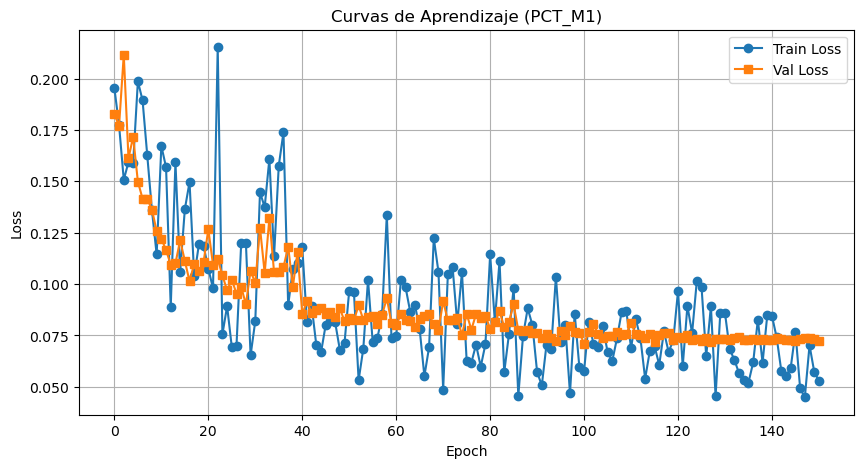

In [7]:
plot_training_curves(LOGS_ROOT)

## Ejecutar Evaluación


In [11]:
evaluate_hdf5()

🧠 Cargando modelo dinámicamente: src.model.LightningSymmetryModel.LightningSymmetryModel


/home/vimunoz/miniconda3/envs/symclean/lib/python3.10/site-packages/lightning/fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


KeyboardInterrupt: 

## Vizualizacion Polyscope

In [151]:
# --- CARGA GLOBAL DEL MODELO PARA VISUALIZACIÓN ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"🧠 Cargando modelo dinámicamente: {MODEL_CLASS_PATH}")
model = load_model_dynamically(MODEL_CLASS_PATH, CHECKPOINT_PATH)
model = model.to(device)
model.eval()
print(f"¡Modelo cargado en {device} y listo para Polyscope! 🚀")

🧠 Cargando modelo dinámicamente: src.model.LightningPCT_M1.LightningPCT_M1


c:\Users\vicho\miniconda3\envs\symclean\lib\site-packages\lightning\fabric\__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


¡Modelo cargado en cuda y listo para Polyscope! 🚀


c:\Users\vicho\miniconda3\envs\symclean\lib\site-packages\lightning\fabric\utilities\cloud_io.py:55: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


### Visualizar una figura

#### Funciones Auxiliares

In [1]:
import polyscope as ps
import numpy as np
import os
import polyscope.imgui as psim 

def create_plane_mesh(center, normal, scale=1.2):
    """
    Genera los vértices y caras (quad) para dibujar un plano 3D en Polyscope.
    """
    normal = normal / np.linalg.norm(normal)
    
    # Buscamos un vector ortogonal al azar para crear la base del plano
    random_vec = np.array([1.0, 0.0, 0.0])
    if np.abs(np.dot(normal, random_vec)) > 0.99:
        random_vec = np.array([0.0, 1.0, 0.0])
        
    u = np.cross(normal, random_vec)
    u = u / np.linalg.norm(u)
    v = np.cross(normal, u)
    
    # Calculamos las 4 esquinas del plano
    corners = np.array([
        center + scale * (u + v),
        center + scale * (u - v),
        center + scale * (-u - v),
        center + scale * (-u + v)
    ])
    faces = np.array([[0, 1, 2, 3]])
    return corners, faces

def inspect_shape_with_polyscope(points_np, gt_planes_np, pred_planes_np, shape_id="Modelo 3D"):
    """
    Abre Polyscope para inspeccionar una figura, sus simetrías reales y las predichas.
    - points_np: Array (N, 3)
    - gt_planes_np: Array (M, 4) con [nx, ny, nz, d]
    - pred_planes_np: Array (K, 4) con [nx, ny, nz, d] 
    """
    ps.init()

    # 1. Extraer el tipo de figura del shape_id (ej. "astroid")
    partes = str(shape_id).split('-')
    tipo_figura = partes[1] if len(partes) > 1 else "sin_clasificar"

    # 2. Definir el panel de la interfaz
    def mi_panel_ui():
        # Este bloque SOLO se ejecuta cuando presionas el botón
        if psim.Button("Guardar Captura de " + str(shape_id)):
            
            # Definimos y CREAMOS la carpeta justo antes de guardar
            carpeta_destino = os.path.join("capturas_tesis", tipo_figura)
            os.makedirs(carpeta_destino, exist_ok=True)
            
            # Armamos la ruta final
            ruta_archivo = os.path.join(carpeta_destino, f"{shape_id}.png")
            
            # Guardamos el pantallazo
            ps.screenshot(ruta_archivo)
            print(f"✅ Captura guardada exitosamente en: {ruta_archivo}")

    # Le pasamos el panel a Polyscope
    ps.set_user_callback(mi_panel_ui)

    # 3. Registrar tus datos
    ps_cloud = ps.register_point_cloud("Nube de Puntos_" + str(shape_id), points_np, radius=0.005)
    ps_cloud.set_color((0.8, 0.8, 0.8))
    
    # 2. Registrar Planos Reales (Ground Truth) en VERDE
    if gt_planes_np is not None and len(gt_planes_np) > 0:
        for i, plane in enumerate(gt_planes_np):
            normal = plane[:3]
            # La distancia 'd' asume la ecuación ax + by + cz + d = 0.
            # El punto más cercano al origen en el plano es -d * normal
            center = -plane[3] * normal 
            
            verts, faces = create_plane_mesh(center, normal)
            ps_mesh = ps.register_surface_mesh(f"GT_Plano_{i}", verts, faces)
            ps_mesh.set_color((0.2, 0.8, 0.2)) # Verde
            ps_mesh.set_transparency(0.4)      # Semitransparente para ver a través

    # 3. Registrar Planos Predichos (DBSCAN) en ROJO
    if pred_planes_np is not None and len(pred_planes_np) > 0:
        for i, plane in enumerate(pred_planes_np):
            normal = plane[:3]
            center = -plane[3] * normal
            
            verts, faces = create_plane_mesh(center, normal)
            ps_mesh = ps.register_surface_mesh(f"Pred_Plano_{i}", verts, faces)
            ps_mesh.set_color((0.8, 0.2, 0.2)) # Rojo
            ps_mesh.set_transparency(0.4)



    print(f"👀 Abriendo visualizador para {shape_id}...")

    ps.show()
    ps.clear_user_callback()
    ps.remove_all_structures()
    
   

ModuleNotFoundError: No module named 'polyscope'

In [64]:
import lzma
import numpy as np

def load_points_from_xz(file_path):
    # Lee el archivo .xz (asumiendo que dentro hay un array de texto o binario)
    with lzma.open(file_path, "rt") as f:
        # Si es un CSV/TXT dentro del XZ:
        return np.loadtxt(f)

    
def load_planes_from_txt(file_path):
    planes = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if not parts or parts[0] != "plane":
                continue
            
            # Extraer componentes: plane nx ny nz px py pz
            # (Asumiendo que los 3 primeros son la normal y los otros 3 un punto en el plano)
            n = np.array([float(parts[1]), float(parts[2]), float(parts[3])])
            p = np.array([float(parts[4]), float(parts[5]), float(parts[6])])
            
            # Calcular 'd' para la ecuación ax + by + cz + d = 0
            # d = -(n · p)
            d = -np.dot(n, p)
            
            planes.append([n[0], n[1], n[2], d])
            
    return np.array(planes) if planes else None


#### Visualizar Random

In [132]:
import h5py
import random

# 1. Pon la ruta a tu dataset de prueba preprocesado
TEST_H5_PATH = "C:/datasets/Symmetria-Intermediate-2-10k-preproc/test.h5"

print("Cargando dataset...")
with h5py.File(TEST_H5_PATH, 'r') as f:
    # 2. Sacamos la lista de todos los modelos y elegimos uno al azar
    shape_ids = list(f.keys())
    #target_id = random.choice(shape_ids)
    target_id = "008998-geometric_petal-undersampling"
    print(f"Figura seleccionada: {target_id}")
    
    # 3. Extraemos los puntos y los planos reales (Ground Truth)
    group = f[target_id]
    points_np = group['points'][:]
    
    if 'planar_symmetries' in group:
        gt_planar_6d = group['planar_symmetries'][:] # Viene como [nx, ny, nz, px, py, pz]
        
        # Convertimos de 6D a 4D [nx, ny, nz, d] para Polyscope
        gt_planar = []
        for plane in gt_planar_6d:
            n = plane[:3]
            p = plane[3:6]
            d = -np.dot(n, p)  # Ahora sí calculamos 'd' con el punto normalizado
            gt_planar.append([n[0], n[1], n[2], d])
            
        gt_planar = np.array(gt_planar)
    else:
        gt_planar = np.array([])

# 4. ¡LA LLAMADA QUE ENCIENDE POLYSCOPE!
# Le pasamos "None" a los planos predichos porque solo queremos ver el Ground Truth por ahora
inspect_shape_with_polyscope(
    points_np=points_np, 
    gt_planes_np=gt_planar, 
    pred_planes_np=None, 
    shape_id=target_id
)

Cargando dataset...
Figura seleccionada: 008998-geometric_petal-undersampling
👀 Abriendo visualizador para 008998-geometric_petal-undersampling...


#### Visualizar Específico

In [131]:
# 1. Definir las rutas de tus archivos específicos
target_id = "008998-geometric_petal-undersampling" # Etiqueta para Polyscope
partes = str(target_id).split('-')
tipo_figura = partes[1] if len(partes) > 1 else "sin_clasificar"
path_xz = "C:/datasets/Symmetria-Intermediate-2-10k/sym-10k-xz-v3.0-9classes-rotprob0.75-rotxroty/test/"+tipo_figura+"/"+target_id+".xz"
path_txt = "C:/datasets/Symmetria-Intermediate-2-10k/sym-10k-xz-v3.0-9classes-rotprob0.75-rotxroty/test/"+tipo_figura+"/"+target_id+"-sym.txt"

print(f"Cargando archivos para: {target_id}")

# 2. Extraer los puntos (antes venían de group['points'])
points_np = load_points_from_xz(path_xz)

# 3. Extraer los planos (antes venían de group['planar_symmetries'])
gt_planar = load_planes_from_txt(path_txt)
print(f"Planos de simetría extraídos: {gt_planar if gt_planar is not None else 'No se encontraron planos'}")

# 4. ¡LA LLAMADA A POLYSCOPE!
inspect_shape_with_polyscope(
    points_np=points_np, 
    gt_planes_np=gt_planar, 
    pred_planes_np=None, 
    shape_id=target_id
)


Cargando archivos para: 008998-geometric_petal-undersampling
Planos de simetría extraídos: [[ 0.          0.12187    -0.99255     0.09167263]
 [-0.79864    -0.59733    -0.07334     0.24967315]]
👀 Abriendo visualizador para 008998-geometric_petal-undersampling...


In [126]:
# 1. Definir las rutas de tus archivos específicos
target_id = "009037-geometric_petal-undersampling" # Etiqueta para Polyscope
partes = str(target_id).split('-')
tipo_figura = partes[1] if len(partes) > 1 else "sin_clasificar"
path_xz = "C:\\datasets\\Symmetria-Easy-10k\\sym-10k-xz-v1.0-repack-rotprob0.5-onlyrotx\\test\\"+tipo_figura+"\\"+target_id+".xz"
path_txt = "C:\\datasets\\Symmetria-Easy-10k\\sym-10k-xz-v1.0-repack-rotprob0.5-onlyrotx\\test\\"+tipo_figura+"\\"+target_id+"-sym.txt"

print(f"Cargando archivos para: {target_id}")

# 2. Extraer los puntos (antes venían de group['points'])
points_np = load_points_from_xz(path_xz)

# 3. Extraer los planos (antes venían de group['planar_symmetries'])
gt_planar = load_planes_from_txt(path_txt)

# 4. ¡LA LLAMADA A POLYSCOPE!
inspect_shape_with_polyscope(
    points_np=points_np, 
    gt_planes_np=gt_planar, 
    pred_planes_np=None, 
    shape_id=target_id
)


Cargando archivos para: 009037-geometric_petal-undersampling
👀 Abriendo visualizador para 009037-geometric_petal-undersampling...


### Visualizar Predicciones en Figura

In [133]:
import polyscope as ps
import polyscope.imgui as psim
import numpy as np

class InteractiveSymmetryViewer:
    def __init__(self, points, gt_planes, pred_planes, confs, shape_id="Modelo"):
        self.points = points
        self.gt_planes = gt_planes
        
        # Guardamos las predicciones originales y confianzas
        self.raw_planes = pred_planes
        self.raw_confs = confs
        
        # --- Variables de Estado del Panel de Control ---
        self.threshold = 0.5           # Deslizador de confianza
        self.show_preds = True         # Checkbox para mostrar/ocultar ROJOS
        self.show_gt = True            # Checkbox para mostrar/ocultar VERDES
        self.merge_mode = True        # Checkbox para modo "Unir Planos"
        self.merge_angle = 5.0         # Ángulo de tolerancia para unir (grados)
        
        # Nombres de las estructuras registradas en Polyscope
        self.pred_mesh_names = []
        
        # Iniciar entorno
        ps.init()
        ps.set_up_dir("y_up")
        
        # 1. Registrar Puntos y Ground Truth
        ps_cloud = ps.register_point_cloud("Nube de Puntos", self.points, radius=0.005)
        ps_cloud.set_color((0.8, 0.8, 0.8))
        self.register_gt_planes()
        
        # 2. Registrar predicciones iniciales
        self.update_predictions_render()
        
        # 3. Conectar el panel de control y mostrar
        ps.set_user_callback(self.ui_callback)
        print(f"👀 Abriendo visualizador interactivo para {shape_id}...")
        ps.show()
        
        # Limpieza al cerrar
        ps.clear_user_callback()
        ps.remove_all_structures()

    def create_plane_mesh(self, center, normal, scale=1.2):
        normal = normal / (np.linalg.norm(normal) + 1e-8)
        random_vec = np.array([1.0, 0.0, 0.0])
        if np.abs(np.dot(normal, random_vec)) > 0.99:
            random_vec = np.array([0.0, 1.0, 0.0])
            
        u = np.cross(normal, random_vec)
        u = u / np.linalg.norm(u)
        v = np.cross(normal, u)
        
        corners = np.array([
            center + scale * (u + v),
            center + scale * (u - v),
            center + scale * (-u - v),
            center + scale * (-u + v)
        ])
        return corners, np.array([[0, 1, 2, 3]])

    def register_gt_planes(self):
        if self.gt_planes is None: return
        for i, plane in enumerate(self.gt_planes):
            normal = plane[:3]
            center = -plane[3] * normal 
            verts, faces = self.create_plane_mesh(center, normal)
            name = f"GT_Plano_{i}"
            ps_mesh = ps.register_surface_mesh(name, verts, faces)
            ps_mesh.set_color((0.2, 0.8, 0.2))
            ps_mesh.set_transparency(0.4)

    def update_predictions_render(self):
        # Borrar predicciones anteriores de la pantalla
        for name in self.pred_mesh_names:
            ps.remove_surface_mesh(name)
        self.pred_mesh_names.clear()
        
        if not self.show_preds:
            return # Si el botón ocultar está activo, salimos aquí

        # Filtrar por el umbral del deslizador actual
        valid_idx = np.where(self.raw_confs >= self.threshold)[0]
        if len(valid_idx) == 0: return
        
        active_planes = self.raw_planes[valid_idx]
        active_confs = self.raw_confs[valid_idx]

        # LÓGICA DE UNIÓN (NMS Geométrico Simple)
        if self.merge_mode:
            # Ordenar de mayor a menor confianza
            sort_idx = np.argsort(active_confs)[::-1]
            active_planes = active_planes[sort_idx]
            
            merged_planes = []
            merge_rad = np.radians(self.merge_angle)
            
            for p1 in active_planes:
                n1 = p1[:3]
                is_unique = True
                for p2 in merged_planes:
                    n2 = p2[:3]
                    # Calcular ángulo entre normales
                    cos_angle = np.clip(np.abs(np.dot(n1, n2)), 0.0, 1.0)
                    if np.arccos(cos_angle) < merge_rad:
                        is_unique = False
                        break
                if is_unique:
                    merged_planes.append(p1)
            active_planes = np.array(merged_planes)

        # Dibujar los planos resultantes
        for i, plane in enumerate(active_planes):
            normal = plane[:3]
            center = -plane[3] * normal
            verts, faces = self.create_plane_mesh(center, normal)
            name = f"Pred_Plano_{i}"
            ps_mesh = ps.register_surface_mesh(name, verts, faces)
            ps_mesh.set_color((0.8, 0.2, 0.2))
            ps_mesh.set_transparency(0.4)
            self.pred_mesh_names.append(name)

    def ui_callback(self):
        # --- CONSTRUCCIÓN DE LA INTERFAZ ---
        psim.PushItemWidth(150)
        
        # Deslizador de Confianza
        changed_thresh, self.threshold = psim.SliderFloat("Threshold de Confianza", self.threshold, 0.0, 1.0)
        
        psim.Separator()
        
        # Botones de Visibilidad
        changed_preds, self.show_preds = psim.Checkbox("Mostrar Predicciones (Rojo)", self.show_preds)
        changed_gt, self.show_gt = psim.Checkbox("Mostrar Ground Truth (Verde)", self.show_gt)
        
        psim.Separator()
        
        # Modo Unión
        changed_merge, self.merge_mode = psim.Checkbox("Unir Planos Similares", self.merge_mode)
        changed_angle, self.merge_angle = psim.SliderFloat("Tolerancia Angular (°)", self.merge_angle, 1.0, 30.0)

        psim.PopItemWidth()

        # --- LÓGICA DE ACTUALIZACIÓN ---
        # Si cambiamos el GT, lo ajustamos directo
        if changed_gt:
            for i in range(len(self.gt_planes)):
                ps.get_surface_mesh(f"GT_Plano_{i}").set_enabled(self.show_gt)

        # Si cambiamos cualquier otra cosa, recalculamos los planos rojos
        if changed_thresh or changed_preds or changed_merge or changed_angle:
            self.update_predictions_render()

In [159]:
import torch
import random
import numpy as np
import h5py

# --- DEFINIR EL DISPOSITIVO (GPU o CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# OJO: Asegúrate de que tu modelo también esté cargado y en el mismo device.
# Si no lo has hecho en esta sesión, deberías tener algo como:
# model = TuModeloAca.load_from_checkpoint("ruta/al/modelo.ckpt").to(device)
# model.eval()

# --- CONFIGURACIÓN RÁPIDA ---
CONF_VISUALIZATION_THRESHOLD = 0.5  # Solo mostramos planos con más de 50% de confianza
# ----------------------------

print("Cargando dataset...")
with h5py.File(TEST_H5_PATH, 'r') as f:
    shape_ids = list(f.keys())
    target_id = random.choice(shape_ids)
    #target_id = "008998-geometric_petal-undersampling"
    print("\n" + "="*40)
    print(f"🔎 Analizando Figura: {target_id}")
    print("="*40)
    
    # group = f[target_id]
    # points_np = group['points'][:]
    # gt_planar = group['planar_symmetries'][:] if 'planar_symmetries' in group else np.array([])

     # 3. Extraemos los puntos y los planos reales (Ground Truth)
    group = f[target_id]
    points_np = group['points'][:]
    
    if 'planar_symmetries' in group:
        gt_planar_6d = group['planar_symmetries'][:] # Viene como [nx, ny, nz, px, py, pz]
        
        # Convertimos de 6D a 4D [nx, ny, nz, d] para Polyscope
        gt_planar = []
        for plane in gt_planar_6d:
            n = plane[:3]
            p = plane[3:6]
            d = -np.dot(n, p)  # Ahora sí calculamos 'd' con el punto normalizado
            gt_planar.append([n[0], n[1], n[2], d])
            
        gt_planar = np.array(gt_planar)
    else:
        gt_planar = np.array([])
    
    # 1. Preparar tensor para el modelo (B, C, N) y mandarlo al device
    points_tensor = torch.tensor(points_np, dtype=torch.float32).unsqueeze(0).transpose(2, 1).to(device)
    
    # 2. Inferencia de la Red
    with torch.no_grad():
        pred_normals, pred_confs, pred_centers = model(points_tensor)
        
        # Extraemos del batch
        confs = pred_confs[0].cpu().numpy()      # Shape: (1024, 32)
        normals = pred_normals[0].cpu().numpy()  # Shape: (1024, 32, 3)
        centers = pred_centers[0].cpu().numpy()  # Shape: (1024, 3)

        print(f"\n📏 Dimensiones crudas del modelo:")
        print(f"Confianzas: {confs.shape} | Normales: {normals.shape} | Centros: {centers.shape}")

        # (Tu código de inferencia normal...)
        # ...
        point_idx, head_idx = np.where(confs > 0.01) # Extraemos casi todo para que el deslizador tenga margen
        
        valid_confs = confs[point_idx, head_idx]
        valid_normals = normals[point_idx, head_idx]
        valid_centers = centers[point_idx]
        
        pred_planes_raw = []
        for i in range(len(valid_confs)):
            n = valid_normals[i]
            c = valid_centers[i]
            d = -np.dot(n, c)
            pred_planes_raw.append([n[0], n[1], n[2], d])
        pred_planes_raw = np.array(pred_planes_raw)

# ¡Llamamos al visor interactivo!
viewer = InteractiveSymmetryViewer(
    points=points_np,
    gt_planes=gt_planar,
    pred_planes=pred_planes_raw,
    confs=valid_confs,          # <--- ¡NUEVO! Le pasamos las confianzas
    shape_id=target_id
)

Cargando dataset...

🔎 Analizando Figura: 000035-m_convexities-gaussian

📏 Dimensiones crudas del modelo:
Confianzas: (1024, 32) | Normales: (1024, 32, 3) | Centros: (1024, 3)
👀 Abriendo visualizador interactivo para 000035-m_convexities-gaussian...


### Modelo Memorizado

In [14]:
import torch
import random
import numpy as np
import h5py

# --- DEFINIR EL DISPOSITIVO (GPU o CPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# OJO: Asegúrate de que tu modelo también esté cargado y en el mismo device.
# Si no lo has hecho en esta sesión, deberías tener algo como:
# model = TuModeloAca.load_from_checkpoint("ruta/al/modelo.ckpt").to(device)
# model.eval()

# --- CONFIGURACIÓN RÁPIDA ---
CONF_VISUALIZATION_THRESHOLD = 0.5  # Solo mostramos planos con más de 50% de confianza
# ----------------------------

# Cambia esta línea al principio de tu script:
TRAIN_H5_PATH = "C:/datasets/Symmetria-Easy-10k-preproc/train.h5" # Asegúrate que sea la ruta correcta

print("Cargando dataset de entrenamiento (Memorizado)...")

with h5py.File(TRAIN_H5_PATH, 'r') as f:
    shape_ids = list(f.keys())
    target_id = shape_ids[7] # Figura 0, 1, 2... hasta la 31 son las que se aprendió de memoria
    
    print("\n" + "="*40)
    print(f"🔎 Analizando Figura Memorizada: {target_id}")
    print("="*40)
    
    group = f[target_id]
    points_np = group['points'][:]
    gt_planar = group['planar_symmetries'][:] if 'planar_symmetries' in group else np.array([])
    
    # 1. Preparar tensor para el modelo (B, C, N) y mandarlo al device
    points_tensor = torch.tensor(points_np, dtype=torch.float32).unsqueeze(0).transpose(2, 1).to(device)
    
    # 2. Inferencia de la Red
    with torch.no_grad():
        pred_normals, pred_confs, pred_centers = model(points_tensor)
        
        # Extraemos del batch
        confs = pred_confs[0].cpu().numpy()      # Shape: (1024, 32)
        normals = pred_normals[0].cpu().numpy()  # Shape: (1024, 32, 3)
        centers = pred_centers[0].cpu().numpy()  # Shape: (1024, 3)

        print(f"\n📏 Dimensiones crudas del modelo:")
        print(f"Confianzas: {confs.shape} | Normales: {normals.shape} | Centros: {centers.shape}")

        # 3. Filtrado Inteligente (Solución a la asimetría de dimensiones)
        # np.where devuelve en qué fila (punto) y columna (cabezal) la confianza > umbral
        point_idx, head_idx = np.where(confs > CONF_VISUALIZATION_THRESHOLD)
        
        # Extraemos los datos exactos usando los índices
        valid_confs = confs[point_idx, head_idx]
        valid_normals = normals[point_idx, head_idx]
        valid_centers = centers[point_idx] # <--- ¡LA MAGIA! Solo pedimos el índice del punto
        
        pred_planes_raw = []
        
        print(f"\n--- Predicciones de la Red que superan el umbral: {len(valid_confs)} ---")
        
        for i in range(len(valid_confs)):
            conf = float(valid_confs[i])
            n = valid_normals[i]
            c = valid_centers[i]
            
            # Ecuación del plano
            d = -np.dot(n, c)
            pred_planes_raw.append([n[0], n[1], n[2], d])
            
            if i < 10:
                print(f"Punto {point_idx[i]:04d} | Cabezal {head_idx[i]:02d} | Confianza: {conf:.4f} | Normal: [{n[0]:.2f}, {n[1]:.2f}, {n[2]:.2f}]")
                
        if len(valid_confs) > 10:
            print(f"... (ocultando {len(valid_confs) - 10} propuestas más)")
            
        pred_planes_raw = np.array(pred_planes_raw)
        
        if len(pred_planes_raw) == 0:
            print("⚠️ La red no predijo ningún plano con suficiente confianza.")
        else:
            print(f"✅ Se visualizarán {len(pred_planes_raw)} planos predichos (ROJO).")
            print(f"✅ Se visualizarán {len(gt_planar)} planos reales (VERDE).")

# 4. ¡Llamamos a Polyscope!
inspect_shape_with_polyscope(
    points_np=points_np, 
    gt_planes_np=gt_planar, 
    pred_planes_np=pred_planes_raw, 
    shape_id=target_id
)

Cargando dataset de entrenamiento (Memorizado)...

🔎 Analizando Figura Memorizada: 000011-lemniscate-uniform

📏 Dimensiones crudas del modelo:
Confianzas: (1024, 32) | Normales: (1024, 32, 3) | Centros: (1024, 3)

--- Predicciones de la Red que superan el umbral: 2048 ---
Punto 0000 | Cabezal 00 | Confianza: 0.9996 | Normal: [0.00, 1.00, 0.01]
Punto 0000 | Cabezal 23 | Confianza: 1.0000 | Normal: [1.00, -0.00, 0.00]
Punto 0001 | Cabezal 00 | Confianza: 0.9997 | Normal: [0.00, 1.00, 0.01]
Punto 0001 | Cabezal 23 | Confianza: 0.9999 | Normal: [1.00, 0.00, 0.00]
Punto 0002 | Cabezal 00 | Confianza: 0.9998 | Normal: [0.00, 1.00, 0.01]
Punto 0002 | Cabezal 23 | Confianza: 0.9999 | Normal: [1.00, -0.00, 0.00]
Punto 0003 | Cabezal 00 | Confianza: 0.9997 | Normal: [0.00, 1.00, 0.01]
Punto 0003 | Cabezal 23 | Confianza: 1.0000 | Normal: [1.00, -0.00, 0.00]
Punto 0004 | Cabezal 00 | Confianza: 0.9997 | Normal: [0.00, 1.00, 0.01]
Punto 0004 | Cabezal 23 | Confianza: 0.9999 | Normal: [1.00, -0.00,